Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31047 entries, 0 to 31046
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Index             31047 non-null  int64 
 1   Order ID          31047 non-null  object
 2   Cust ID           31047 non-null  int64 
 3   Gender            31047 non-null  object
 4   Age               31047 non-null  int64 
 5   Age Group         31047 non-null  object
 6   Date              31047 non-null  object
 7   Month             31047 non-null  object
 8   Status            31047 non-null  object
 9   Channel           31047 non-null  object
 10  SKU               31047 non-null  object
 11  Category          31047 non-null  object
 12  Size              31047 non-null  object
 13  Qty               31047 non-null  int64 
 14  currency          31047 non-null  object
 15  Amount            31047 non-null  int64 
 16  ship-city         31047 non-null  object
 17

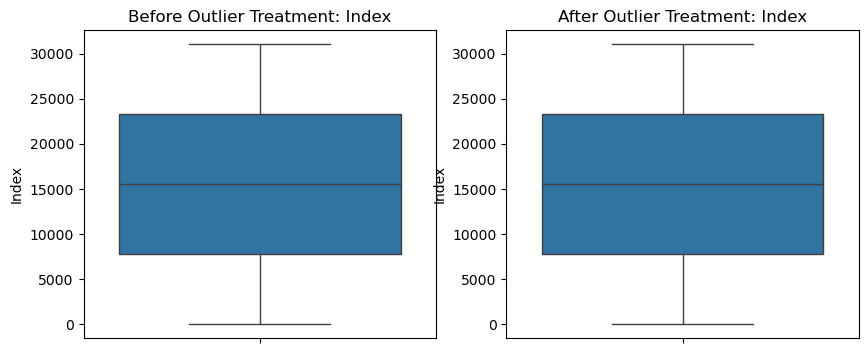

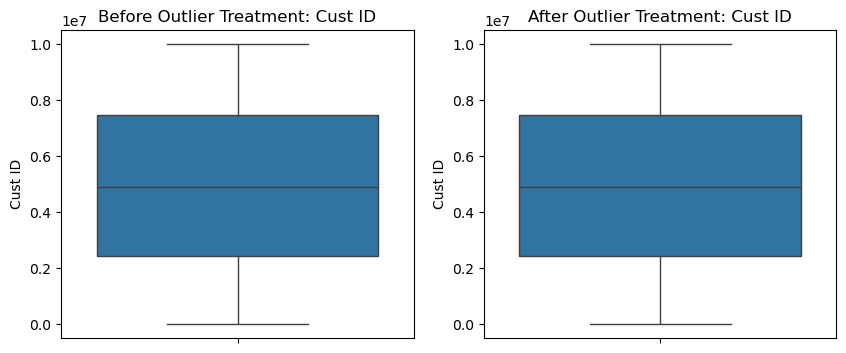

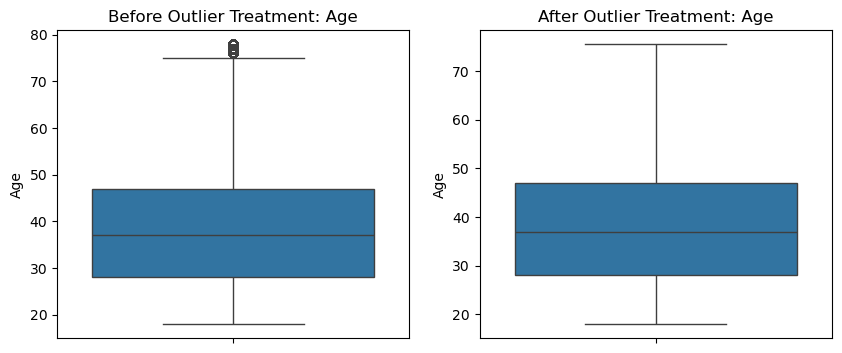

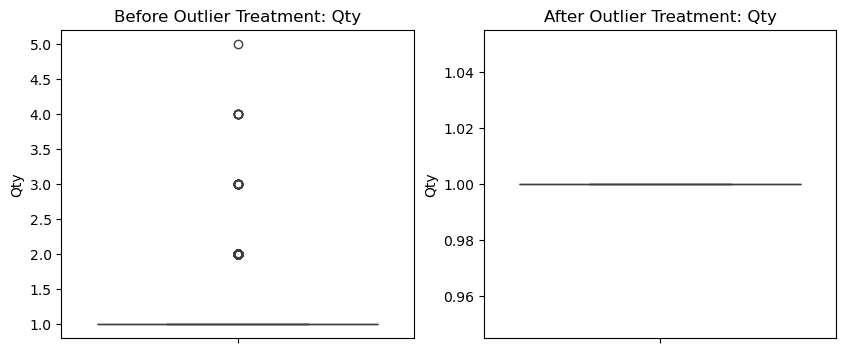

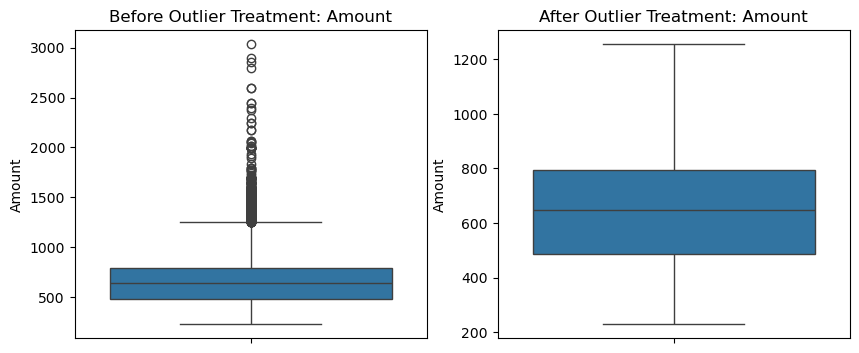

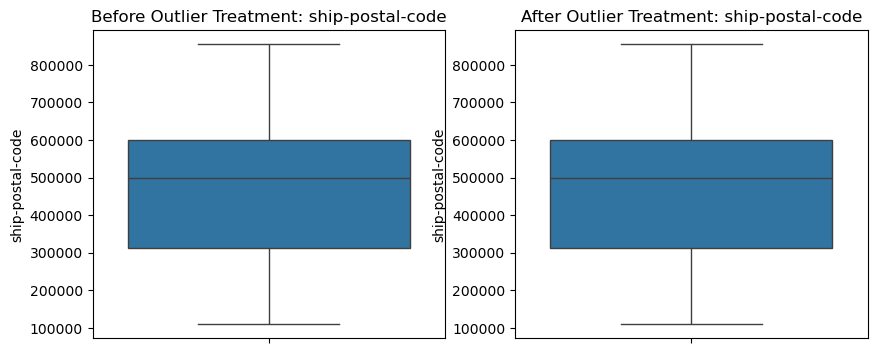

Skipping encoding for column: Date due to mixed data types

Descriptive Statistics:
                          mean           50%          std
Index            -1.171765e-16 -3.701591e-07     1.000016
Order ID          1.422073e+04  1.418400e+04  8205.064278
Cust ID           1.039026e-16 -9.287244e-03     1.000016
Gender            6.942056e-01  1.000000e+00     0.460751
Age              -3.432905e-18 -1.639196e-01     1.000016
Age Group         5.454633e-01  0.000000e+00     0.772848
Month             5.432602e+00  5.000000e+00     3.424764
Status            1.056785e+00  1.000000e+00     0.418632
Channel           2.338970e+00  2.000000e+00     1.596382
SKU               2.871603e+03  3.167000e+03  1531.199816
Category          5.243437e+00  5.000000e+00     1.515133
Size              6.223661e+00  6.000000e+00     2.817650
Qty               0.000000e+00  0.000000e+00     0.000000
currency          0.000000e+00  0.000000e+00     0.000000
Amount           -4.211030e-17 -1.198560e-01  

In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the dataset
dataset_path = "C:/Users/sriya/Downloads/Fashion_Sales_Dataset.xlsx"
df = pd.read_excel(dataset_path)

# Display basic info about the dataset
print("Dataset Info:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Handle missing values (Mean/Median/Mode Imputation)
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())  # Using median for numerical columns
    else:
        df[col] = df[col].fillna(df[col].mode()[0])  # Using mode for categorical columns
# Store a copy before outlier treatment
before_outlier_treatment = df.copy()

# Detect and treat outliers using IQR method
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

# Visualize numerical features before and after outlier treatment
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.boxplot(y=before_outlier_treatment[col])
    plt.title(f'Before Outlier Treatment: {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col])
    plt.title(f'After Outlier Treatment: {col}')
    plt.show()

# Convert datetime columns to string before encoding
for col in df.columns:
    if np.issubdtype(df[col].dtype, np.datetime64):
        df[col] = df[col].astype(str)

# Encode categorical variables
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    try:
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le
    except TypeError:
        print(f"Skipping encoding for column: {col} due to mixed data types")

# Scale numerical features
scaler = StandardScaler()
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Calculate descriptive statistics
stats = df.describe().T
print("\nDescriptive Statistics:")
print(stats[['mean', '50%', 'std']])  # Mean, Median (50%), Std Dev

# Save the final cleaned dataset
cleaned_path = 'C:/Users/sriya/Downloads/Fashion_Sales_Cleaned.xlsx'
df.to_excel(cleaned_path, index=False)
print(f"Final cleaned dataset saved to {cleaned_path}")
